# Createur procedural d'environnements avec agent RL

## Concept
- Un **generateur** cree des labyrinthes sous forme de matrices textuelles
- Un **agent RL** (Q-Learning) tente de resoudre chaque labyrinthe
- Le generateur est **recompense** s'il produit un niveau *faisable mais challengeant*

Symboles : `S`=depart, `E`=sortie, `#`=mur, `.`=libre

## Parametres du projet

Modifiez cette cellule pour configurer l'experience.

In [164]:
# ==================================================================
# PARAMETRES DU PROJET
# Modifiez ces valeurs pour configurer le labyrinthe et l'entrainement
# ==================================================================

# --- Labyrinthe ---
MAZE_HEIGHT = 32       # Hauteur du labyrinthe (nombre de lignes)
MAZE_WIDTH  = 32       # Largeur du labyrinthe (nombre de colonnes)

# Position du point d'arrivee E (indices dans la grille)
# CONTRAINTE : les valeurs doivent etre des nombres IMPAIRS dans [1, dim-2]
#   Pour une grille 32x32 : valeurs valides = 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31
#   Mettre None = position automatique (coin bas-droite atteignable)
MAZE_END_ROW = 31    # Ligne de E   (ex: 13 pour bas,  1 pour haut)
MAZE_END_COL = 31    # Colonne de E (ex: 13 pour droite, 1 pour gauche)

# Le generateur utilise le DFS (Recursive Backtracking) pour creer des
# labyrinthes complexes et sinueux. Les bordures sont toujours des murs.
#
# wall_prob = fraction des murs DFS supplementaires qui RESTENT des murs
#   1.0 = labyrinthe DFS pur, maximum de complexite (aucun raccourci)
#   0.0 = tous les murs supplementaires sont ouverts (labyrinthe tres facile)
#   Bonne plage : 0.50 a 0.95
WALL_PROB_INIT = 0.70  # Complexite initiale
WALL_PROB_MIN  = 0.10  # Minimum (beaucoup de raccourcis)
WALL_PROB_MAX  = 0.98  # Maximum (presque DFS pur)

# --- Entrainement ---
N_LEVELS           = 60   # Nombre de labyrinthes generes
EPISODES_PER_LEVEL = 500  # Episodes d'entrainement par labyrinthe
VERBOSE_EVERY      = 10   # Afficher les stats toutes les N niveaux

# --- Agent Q-Learning ---
AGENT_LR            = 0.1   # Taux d'apprentissage de l'agent
AGENT_GAMMA         = 0.95  # Facteur de discount (importance du futur)
AGENT_EPSILON       = 1.0   # Taux d'exploration initial (1.0 = 100% aleatoire)
AGENT_EPSILON_DECAY = 0.995 # Decroissance de l'exploration a chaque episode
AGENT_EPSILON_MIN   = 0.05  # Taux d'exploration minimal

# --- Generateur ---
GENERATOR_LR = 0.05  # Vitesse d'adaptation du generateur

# --- Reproductibilite ---
RANDOM_SEED = 42

# --- Validation de MAZE_END ---
def _compute_end_pos(height, width, end_row, end_col):
    max_r = 1 + 2 * ((height - 3) // 2)
    max_c = 1 + 2 * ((width  - 3) // 2)
    r = end_row if end_row is not None else max_r
    c = end_col if end_col is not None else max_c
    # Arrondir a la salle DFS la plus proche (valeur impaire)
    r = max(1, min(r, max_r))
    c = max(1, min(c, max_c))
    if r % 2 == 0: r -= 1
    if c % 2 == 0: c -= 1
    return (r, c)

MAZE_END_POS = _compute_end_pos(MAZE_HEIGHT, MAZE_WIDTH, MAZE_END_ROW, MAZE_END_COL)

print('Parametres charges :')
print(f'  Labyrinthe   : {MAZE_HEIGHT}x{MAZE_WIDTH}')
print(f'  S=(1,1)  E={MAZE_END_POS}')
print(f'  Complexite   : init={WALL_PROB_INIT:.0%}  min={WALL_PROB_MIN:.0%}  max={WALL_PROB_MAX:.0%}')
print(f'  Entrainement : {N_LEVELS} niveaux x {EPISODES_PER_LEVEL} episodes')
print(f'  Agent        : lr={AGENT_LR}  gamma={AGENT_GAMMA}  eps_decay={AGENT_EPSILON_DECAY}')
print(f'  Generateur   : lr={GENERATOR_LR}')


Parametres charges :
  Labyrinthe   : 32x32
  S=(1,1)  E=(29, 29)
  Complexite   : init=70%  min=10%  max=98%
  Entrainement : 60 niveaux x 500 episodes
  Agent        : lr=0.1  gamma=0.95  eps_decay=0.995
  Generateur   : lr=0.05


## 1. Imports

In [165]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
import warnings
warnings.filterwarnings('ignore')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Imports OK')

Imports OK


## 2. L'environnement Labyrinthe (`MazeEnv`)

Represente un labyrinthe. L'agent s'y deplace case par case.
A chaque pas : `step(action)` retourne `(nouvel_etat, recompense, termine)`.

In [166]:
class MazeEnv:
    '''
    Environnement labyrinthe pour l'agent RL.
    Grille textuelle : S=depart  E=sortie  #=mur  .=libre

    Recompenses :
      +100  quand l'agent atteint E
       -10  si l'agent depasse max_steps (timeout)
       -0.1 a chaque pas normal (encourage les chemins courts)
    '''
    ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # haut, bas, gauche, droite

    def __init__(self, grid):
        self.grid   = [list(row) for row in grid]
        self.height = len(self.grid)
        self.width  = len(self.grid[0])
        self.start  = self._find('S')
        self.end    = self._find('E')
        self.agent_pos = self.start
        self.steps     = 0
        self.max_steps = self.height * self.width * 2

    def _find(self, symbol):
        for r in range(self.height):
            for c in range(self.width):
                if self.grid[r][c] == symbol:
                    return (r, c)
        return None

    def reset(self):
        self.agent_pos = self.start
        self.steps = 0
        return self.agent_pos

    def step(self, action):
        self.steps += 1
        dr, dc = self.ACTIONS[action]
        r, c   = self.agent_pos
        nr, nc = r + dr, c + dc

        # Mouvement valide = dans la grille ET pas un mur
        if (0 <= nr < self.height and 0 <= nc < self.width
                and self.grid[nr][nc] != '#'):
            self.agent_pos = (nr, nc)

        if self.agent_pos == self.end:
            return self.agent_pos, 100.0, True    # victoire
        elif self.steps >= self.max_steps:
            return self.agent_pos, -10.0, True    # timeout
        else:
            return self.agent_pos, -0.1,  False   # pas normal

    def render(self, ax=None):
        show = ax is None
        if show:
            fig, ax = plt.subplots(figsize=(self.width * 0.7, self.height * 0.7))
        color_map = {'#': 'black', '.': 'white', 'S': 'green', 'E': 'red'}
        for r in range(self.height):
            for c in range(self.width):
                cell = self.grid[r][c]
                rect = mpatches.FancyBboxPatch(
                    (c, self.height - r - 1), 1, 1,
                    boxstyle='square,pad=0',
                    facecolor=color_map.get(cell, 'white'),
                    edgecolor='gray', linewidth=0.5)
                ax.add_patch(rect)
                if cell in ('S', 'E'):
                    ax.text(c + 0.5, self.height - r - 0.5, cell,
                            ha='center', va='center',
                            color='white', fontweight='bold', fontsize=10)
        ar, ac = self.agent_pos
        ax.plot(ac + 0.5, self.height - ar - 0.5, 'bo', markersize=10)
        ax.set_xlim(0, self.width)
        ax.set_ylim(0, self.height)
        ax.set_aspect('equal')
        ax.axis('off')
        if show:
            plt.tight_layout()
            plt.show()

print('Classe MazeEnv definie')

Classe MazeEnv definie


## 3. Le Generateur Procedural (`MazeGenerator`)

Les cases de **bordure sont toujours des murs** (`#`).
La generation utilise le **DFS (Recursive Backtracking)** — l'algorithme standard
pour les labyrinthes complexes et sinueux, qui garantit un chemin toujours solvable.

### Algorithme de generation

1. Toutes les cases = mur
2. DFS depuis `S` : creuse des passages en explorant aleatoirement (maze parfait)
3. Ouvre `(1 - wall_prob)` des murs restants comme raccourcis

`wall_prob` eleve → peu de raccourcis → labyrinthe tortueux
`wall_prob` faible → beaucoup de raccourcis → labyrinthe facile

### Logique de recompense

```
recompense = steps_pris / max_steps
```

Plus l'agent prend de pas, meilleure est la recompense.
Le generateur apprend a controler `wall_prob` pour maximiser la difficulte sans bloquer l'agent.

| Situation | Recompense | Action generateur |
|---|---|---|
| Beaucoup de pas (labyrinthe dur) | elevee | stabilise |
| Peu de pas (trop facile) | faible | augmente wall_prob |
| Agent bloque | `0` | reduit wall_prob |


In [167]:
class MazeGenerator:
    '''
    Generateur procedural de labyrinthes via DFS (Recursive Backtracking).

    Generation :
      1. Toutes les cases = mur (#)
      2. DFS depuis S creuse un labyrinthe parfait (sinueux, toujours soluble)
      3. Ouvre (1 - wall_prob) des murs restants comme raccourcis
         -> wall_prob eleve = peu de raccourcis = plus complexe
         -> wall_prob faible = beaucoup de raccourcis = plus facile

    Le generateur apprend wall_prob pour maximiser les pas de l'agent.
    '''

    def __init__(self, height=MAZE_HEIGHT, width=MAZE_WIDTH,
                 end_pos=MAZE_END_POS,
                 wall_prob=WALL_PROB_INIT,
                 wall_prob_min=WALL_PROB_MIN,
                 wall_prob_max=WALL_PROB_MAX,
                 learning_rate=GENERATOR_LR):
        self.height = height
        self.width  = width
        self.learning_rate = learning_rate
        self.reward_history    = []
        self.wall_prob_history = []

        self.wall_prob     = float(np.clip(wall_prob, wall_prob_min, wall_prob_max))
        self.wall_prob_min = wall_prob_min
        self.wall_prob_max = wall_prob_max

        self.start_pos = (1, 1)
        self.end_pos   = end_pos   # configurable via MAZE_END_ROW / MAZE_END_COL

        self.n_interior = (height - 2) * (width - 2)

        print(f'  Labyrinthe    : {height}x{width}')
        print(f'  S={self.start_pos}  E={self.end_pos}')
        print(f'  wall_prob init: {self.wall_prob:.0%}'
              f'  [{self.wall_prob_min:.0%} — {self.wall_prob_max:.0%}]')

    # ------------------------------------------------------------------
    # Generation
    # ------------------------------------------------------------------

    def generate(self):
        '''Genere un labyrinthe complexe via DFS. Toujours soluble.'''
        return self._create_dfs_maze()

    def _create_dfs_maze(self):
        '''
        DFS (Recursive Backtracking) :
          - Creuse un labyrinthe parfait depuis S (chemin unique, tres sinueux)
          - Ouvre (1 - wall_prob) des murs restants pour ajouter des raccourcis
        '''
        grid = [['#' for _ in range(self.width)] for _ in range(self.height)]

        sr, sc = self.start_pos

        # --- DFS iteratif ---
        visited = {(sr, sc)}
        stack   = [(sr, sc)]
        grid[sr][sc] = '.'

        while stack:
            r, c = stack[-1]

            neighbors = []
            for dr, dc in [(0, 2), (0, -2), (2, 0), (-2, 0)]:
                nr, nc = r + dr, c + dc
                if (1 <= nr <= self.height - 2 and
                    1 <= nc <= self.width  - 2 and
                    (nr, nc) not in visited):
                    neighbors.append((nr, nc, r + dr // 2, c + dc // 2))

            if neighbors:
                nr, nc, wr, wc = random.choice(neighbors)
                grid[wr][wc] = '.'
                grid[nr][nc] = '.'
                visited.add((nr, nc))
                stack.append((nr, nc))
            else:
                stack.pop()

        # --- Raccourcis supplementaires selon (1 - wall_prob) ---
        remaining_walls = [
            (r, c)
            for r in range(1, self.height - 1)
            for c in range(1, self.width  - 1)
            if grid[r][c] == '#'
        ]
        n_extra = round((1.0 - self.wall_prob) * len(remaining_walls))
        for r, c in random.sample(remaining_walls, min(n_extra, len(remaining_walls))):
            grid[r][c] = '.'

        er, ec = self.end_pos
        grid[sr][sc] = 'S'
        grid[er][ec] = 'E'
        return [''.join(row) for row in grid]

    def _has_path(self, grid):
        start = end = None
        for r, row in enumerate(grid):
            for c, cell in enumerate(row):
                if cell == 'S': start = (r, c)
                elif cell == 'E': end   = (r, c)
        if not start or not end:
            return False
        queue, visited = deque([start]), {start}
        while queue:
            r, c = queue.popleft()
            if (r, c) == end:
                return True
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if (0 <= nr < len(grid) and 0 <= nc < len(grid[0])
                        and (nr, nc) not in visited
                        and grid[nr][nc] != '#'):
                    visited.add((nr, nc))
                    queue.append((nr, nc))
        return False

    def shortest_path(self, grid):
        start = end = None
        for r, row in enumerate(grid):
            for c, cell in enumerate(row):
                if cell == 'S': start = (r, c)
                elif cell == 'E': end   = (r, c)
        queue, visited = deque([(start, 0)]), {start}
        while queue:
            (r, c), dist = queue.popleft()
            if (r, c) == end:
                return dist
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                nr, nc = r + dr, c + dc
                if (0 <= nr < len(grid) and 0 <= nc < len(grid[0])
                        and (nr, nc) not in visited
                        and grid[nr][nc] != '#'):
                    visited.add((nr, nc))
                    queue.append(((nr, nc), dist + 1))
        return float('inf')

    # ------------------------------------------------------------------
    # Signal de recompense
    # ------------------------------------------------------------------

    def compute_generator_reward(self, agent_solved, steps_taken, grid):
        if not agent_solved:
            return 0.0
        max_steps = self.height * self.width * 2
        return min(1.0, steps_taken / max_steps)

    # ------------------------------------------------------------------
    # Mise a jour (apprentissage du generateur)
    # ------------------------------------------------------------------

    def update(self, agent_solved, generator_reward):
        self.reward_history.append(generator_reward)
        self.wall_prob_history.append(self.wall_prob)

        if not agent_solved:
            self.wall_prob -= self.learning_rate * 0.5
        elif generator_reward < 0.3:
            self.wall_prob += self.learning_rate * (0.3 - generator_reward)
        else:
            self.wall_prob -= self.learning_rate * 0.05

        self.wall_prob = float(np.clip(
            self.wall_prob, self.wall_prob_min, self.wall_prob_max))

print('Classe MazeGenerator definie')


Classe MazeGenerator definie


## 4. L'Agent RL (`QLearningAgent`)

Apprend a naviguer dans les labyrinthes via **Q-Learning** :
- **Table Q** : pour chaque case `(r, c)`, stocke la valeur de chaque action
- **Mise a jour Bellman** : `Q(s,a) <- Q(s,a) + lr * (r + gamma*max Q(s') - Q(s,a))`
- **Politique epsilon-greedy** : explore aleatoirement avec probabilite epsilon, sinon exploite la meilleure action

In [168]:
class QLearningAgent:
    '''
    Agent Q-Learning tabulaire.
    q_table : dict { (ligne, colonne) -> array de 4 valeurs (une par action) }
    '''

    def __init__(self,
                 n_actions=4,
                 lr=AGENT_LR,
                 gamma=AGENT_GAMMA,
                 epsilon=AGENT_EPSILON,
                 epsilon_decay=AGENT_EPSILON_DECAY,
                 epsilon_min=AGENT_EPSILON_MIN):
        self.n_actions     = n_actions
        self.lr            = lr
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        self.q_table       = {}  # initialise a la premiere visite de chaque case

    def _get_q(self, state):
        '''Retourne les valeurs Q de l'etat (cree l'entree si inexistante).'''
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.n_actions)
        return self.q_table[state]

    def choose_action(self, state):
        '''Politique epsilon-greedy.'''
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)  # exploration
        return int(np.argmax(self._get_q(state)))          # exploitation

    def update(self, state, action, reward, next_state, done):
        '''Mise a jour de la table Q via la formule de Bellman.'''
        target = reward if done else reward + self.gamma * np.max(self._get_q(next_state))
        self._get_q(state)[action] += self.lr * (target - self._get_q(state)[action])

    def run_episode(self, env):
        '''
        Joue un episode complet.
        Retourne (resolu: bool, nombre_de_pas: int)
        '''
        state = env.reset()
        while True:
            action = self.choose_action(state)
            next_state, reward, done = env.step(action)
            self.update(state, action, reward, next_state, done)
            state = next_state
            if done:
                solved = (state == env.end)
                self.epsilon = max(self.epsilon_min,
                                   self.epsilon * self.epsilon_decay)
                return solved, env.steps

print('Classe QLearningAgent definie')

Classe QLearningAgent definie


## 5. Boucle d'entrainement

A chaque niveau :
1. Le generateur cree un labyrinthe
2. L'agent s'entraine dessus (`EPISODES_PER_LEVEL` fois)
3. On mesure ses performances (taux de reussite, nombre de pas)
4. Le generateur recoit une recompense et ajuste `wall_prob`

In [169]:
def train(n_levels=N_LEVELS,
          episodes_per_level=EPISODES_PER_LEVEL,
          maze_height=MAZE_HEIGHT,
          maze_width=MAZE_WIDTH,
          verbose_every=VERBOSE_EVERY):
    '''
    Boucle principale : generation -> entrainement agent -> feedback -> mise a jour generateur.
    '''
    generator = MazeGenerator(height=maze_height, width=maze_width)
    agent     = QLearningAgent()

    history = {'level': [], 'gen_reward': [], 'solve_rate': [],
               'avg_steps': [], 'wall_prob': []}

    print(f'Labyrinthe : {maze_height}x{maze_width}')
    print(f'Entrainement : {n_levels} niveaux x {episodes_per_level} episodes')
    print('-' * 68)

    for level_idx in range(n_levels):

        # 1. Generer un labyrinthe soluble
        grid = generator.generate()
        env  = MazeEnv(grid)

        # 2. Entrainer l'agent sur ce labyrinthe
        solve_count = 0
        total_steps = 0
        last_solved, last_steps = False, 0

        for _ in range(episodes_per_level):
            solved, steps = agent.run_episode(env)
            if solved:
                solve_count += 1
                total_steps += steps
                last_solved, last_steps = True, steps

        solve_rate = solve_count / episodes_per_level
        avg_steps  = total_steps / max(solve_count, 1)

        # 3. Recompense du generateur : score_murs * score_pas
        gen_reward = generator.compute_generator_reward(last_solved, last_steps, grid)

        # 4. Mise a jour du generateur (passe aussi agent_solved pour distinguer
        #    "trop difficile" de "trop facile")
        generator.update(last_solved, gen_reward)

        history['level'].append(level_idx + 1)
        history['gen_reward'].append(gen_reward)
        history['solve_rate'].append(solve_rate)
        history['avg_steps'].append(avg_steps)
        history['wall_prob'].append(generator.wall_prob)

        if (level_idx + 1) % verbose_every == 0:
            print(f'Niveau {level_idx+1:3d} | '
                  f'Resolution: {solve_rate:.0%} | '
                  f'Moy. pas: {avg_steps:6.1f} | '
                  f'Recomp. gene: {gen_reward:.3f} | '
                  f'wall_prob: {generator.wall_prob:.3f}')

    print('-' * 68)
    print(f'Termine ! Epsilon agent: {agent.epsilon:.3f} | '
          f'wall_prob final: {generator.wall_prob:.3f}')
    return generator, agent, history

print('Fonction train() definie')

Fonction train() definie


## 6. Lancement de l'entrainement

Utilise les parametres definis dans la cellule **Parametres** en haut.

In [170]:
generator, agent, history = train(
    n_levels           = N_LEVELS,
    episodes_per_level = EPISODES_PER_LEVEL,
    maze_height        = MAZE_HEIGHT,
    maze_width         = MAZE_WIDTH,
    verbose_every      = VERBOSE_EVERY,
)

  Labyrinthe    : 32x32
  S=(1, 1)  E=(29, 29)
  wall_prob init: 70%  [10% — 98%]
Labyrinthe : 32x32
Entrainement : 60 niveaux x 500 episodes
--------------------------------------------------------------------
Niveau  10 | Resolution: 87% | Moy. pas:  131.4 | Recomp. gene: 0.034 | wall_prob: 0.829
Niveau  20 | Resolution: 77% | Moy. pas:   73.4 | Recomp. gene: 0.030 | wall_prob: 0.920
Niveau  30 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | wall_prob: 0.822
Niveau  40 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | wall_prob: 0.800
Niveau  50 | Resolution: 66% | Moy. pas:  139.6 | Recomp. gene: 0.045 | wall_prob: 0.747
Niveau  60 | Resolution: 82% | Moy. pas:   85.5 | Recomp. gene: 0.079 | wall_prob: 0.784
--------------------------------------------------------------------
Termine ! Epsilon agent: 0.050 | wall_prob final: 0.784


## 7. Visualisation des resultats

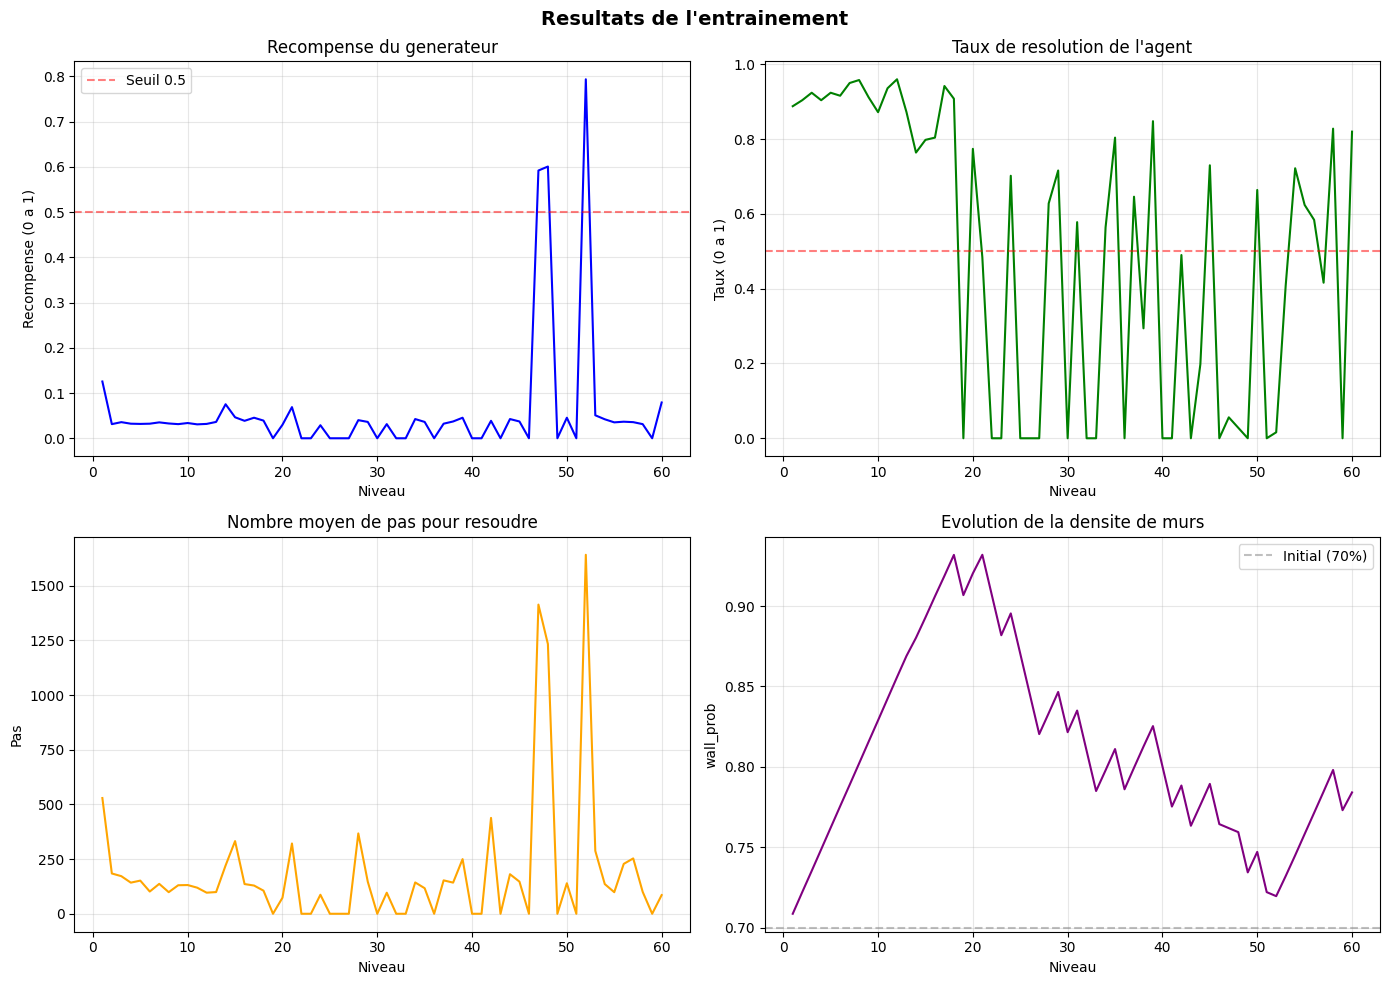

In [171]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Resultats de l'entrainement", fontsize=14, fontweight='bold')
levels = history['level']

# 1. Recompense du generateur
axes[0,0].plot(levels, history['gen_reward'], color='blue', linewidth=1.5)
axes[0,0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Seuil 0.5')
axes[0,0].set_title('Recompense du generateur')
axes[0,0].set_xlabel('Niveau')
axes[0,0].set_ylabel('Recompense (0 a 1)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Taux de resolution
axes[0,1].plot(levels, history['solve_rate'], color='green', linewidth=1.5)
axes[0,1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[0,1].set_title("Taux de resolution de l'agent")
axes[0,1].set_xlabel('Niveau')
axes[0,1].set_ylabel('Taux (0 a 1)')
axes[0,1].grid(True, alpha=0.3)

# 3. Nombre moyen de pas
axes[1,0].plot(levels, history['avg_steps'], color='orange', linewidth=1.5)
axes[1,0].set_title('Nombre moyen de pas pour resoudre')
axes[1,0].set_xlabel('Niveau')
axes[1,0].set_ylabel('Pas')
axes[1,0].grid(True, alpha=0.3)

# 4. Evolution de wall_prob
axes[1,1].plot(levels, history['wall_prob'], color='purple', linewidth=1.5)
axes[1,1].axhline(y=WALL_PROB_INIT, color='gray', linestyle='--', alpha=0.5,
                   label=f'Initial ({WALL_PROB_INIT:.0%})')
axes[1,1].set_title('Evolution de la densite de murs')
axes[1,1].set_xlabel('Niveau')
axes[1,1].set_ylabel('wall_prob')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Demonstration finale

Genere 3 labyrinthes avec le generateur entraine et affiche les performances de l'agent.

wall_prob final : 0.784

Labyrinthe 1
  Resolu    : NON
  Pas pris  : 2048 | Optimal : 58 | Ratio : 35.31x
  Recompense generateur : 0.00

Labyrinthe 2
  Resolu    : NON
  Pas pris  : 2048 | Optimal : 56 | Ratio : 36.57x
  Recompense generateur : 0.00

Labyrinthe 3
  Resolu    : NON
  Pas pris  : 2048 | Optimal : 58 | Ratio : 35.31x
  Recompense generateur : 0.00


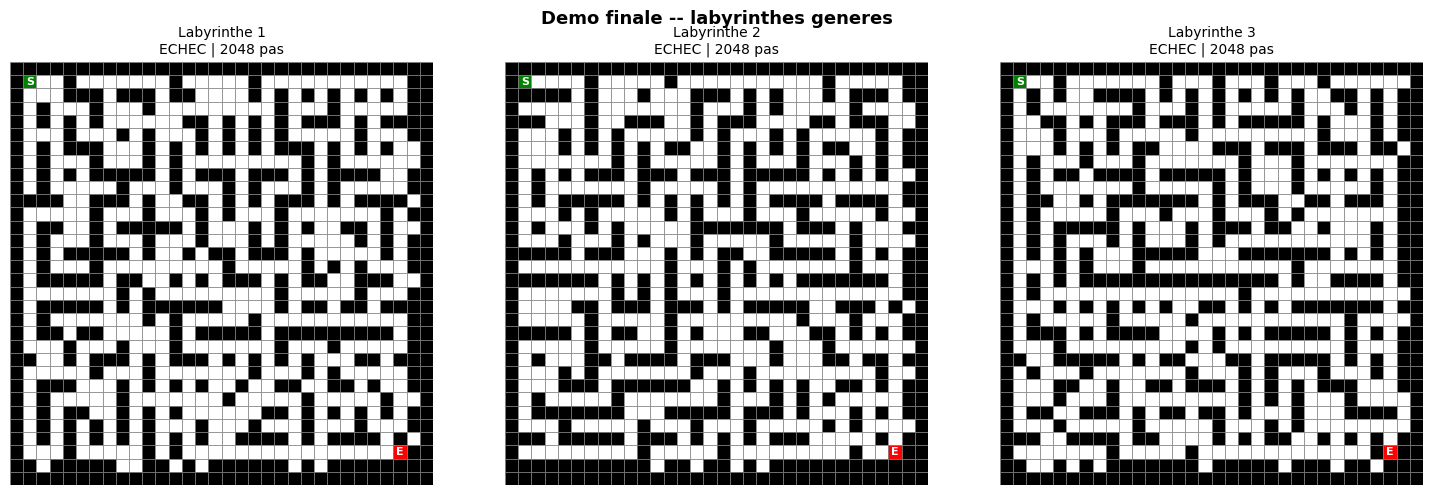

In [172]:
agent.epsilon = 0.0  # mode exploitation pure (plus d'exploration aleatoire)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Demo finale -- labyrinthes generes', fontsize=13, fontweight='bold')

print(f'wall_prob final : {generator.wall_prob:.3f}')
print('=' * 55)

for i in range(3):
    grid = generator.generate()
    env  = MazeEnv(grid)
    solved, steps = agent.run_episode(env)
    optimal    = generator.shortest_path(grid)
    gen_reward = generator.compute_generator_reward(solved, steps, grid)

    print(f'\nLabyrinthe {i+1}')
    if MAZE_HEIGHT <= 12 and MAZE_WIDTH <= 12:
        for row in grid:
            print('  ' + row)
    print(f'  Resolu    : {"OUI" if solved else "NON"}')
    if optimal != float('inf'):
        print(f'  Pas pris  : {steps} | Optimal : {optimal} | Ratio : {steps/optimal:.2f}x')
    print(f'  Recompense generateur : {gen_reward:.2f}')

    ax = axes[i]
    color_map = {'#': 'black', '.': 'white', 'S': 'green', 'E': 'red'}
    h, w = env.height, env.width
    for r in range(h):
        for c in range(w):
            cell = env.grid[r][c]
            rect = mpatches.FancyBboxPatch(
                (c, h-r-1), 1, 1, boxstyle='square,pad=0',
                facecolor=color_map.get(cell, 'white'),
                edgecolor='gray', linewidth=0.5)
            ax.add_patch(rect)
            if cell in ('S', 'E'):
                ax.text(c+0.5, h-r-0.5, cell, ha='center', va='center',
                        color='white', fontweight='bold', fontsize=8)
    status = f'{"RESOLU" if solved else "ECHEC"} | {steps} pas'
    ax.set_title(f'Labyrinthe {i+1}\n{status}', fontsize=10)
    ax.set_xlim(0, w)
    ax.set_ylim(0, h)
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Resume du projet

### Architecture

| Composant | Role |
|---|---|
| **MazeEnv** | Environnement RL (grille, deplacements, recompenses) |
| **MazeGenerator** | Genere des labyrinthes, apprend a ajuster la densite de murs |
| **QLearningAgent** | Apprend a resoudre les labyrinthes via Q-Learning |
| **train()** | Boucle qui fait cooperer les deux composants |

### Guide des parametres

| Parametre | Effet |
|---|---|
| `MAZE_HEIGHT / MAZE_WIDTH` | Taille du labyrinthe (plus grand = plus lent) |
| `WALL_PROB_INIT` | Densite de murs de depart (0.1 = peu de murs, 0.5 = dense) |
| `WALL_PROB_MIN / MAX` | Bornes : le generateur ne sort jamais de cet intervalle |
| `N_LEVELS` | Nombre de labyrinthes generes au total |
| `EPISODES_PER_LEVEL` | Temps d'entrainement par labyrinthe (plus = meilleur agent) |
| `AGENT_LR` | Vitesse d'apprentissage de l'agent (0.01 lent ... 0.5 rapide) |
| `AGENT_GAMMA` | Importance du futur (0=myope, 1=tres prevoyant) |
| `AGENT_EPSILON_DECAY` | Decroissance de l'exploration (proche de 1 = lent) |
| `GENERATOR_LR` | Vitesse d'adaptation du generateur |

### Idees d'extension
- Remplacer Q-Learning par un **Deep Q-Network (DQN)**
- Utiliser un **reseau neuronal** pour le generateur
- Ajouter des **ennemis** ou des **bonus** dans le labyrinthe
- Implementer **PAIRED** ou **PLR** (algorithmes SOTA de generation de niveaux)